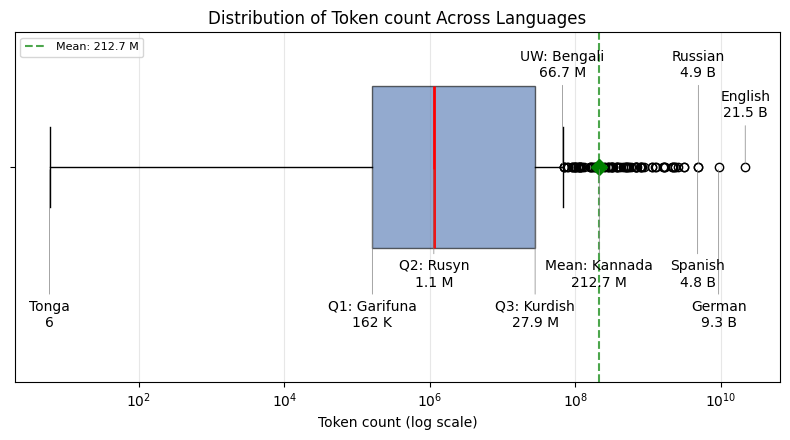

Q1: 162,368  |  Median: 1,136,369  |  Q3: 27,945,331  |  Mean: 212,731,274
Min: 6  |  Max: 21,496,075,402  |  Count: 443
Upper whisker limit: 69,619,776

── Landmark languages ──
  Min    : Tonga                                    6
  Q1     : Garifuna                           162,804
  Median : Rusyn                            1,136,369
  Q3     : Kurdish                         27,101,373
  UW     : Bengali                         66,691,412
  Mean   : Kannada                        206,372,536
  Max    : English                     21,496,075,402


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../../../results/1_process/3_truncate/statistics.csv")
sc = pd.read_csv("../../../src/1_process/0_download/leipzig/lepzig_shortcuts.csv")
code_to_name = dict(zip(sc["code"], sc["language"]))
df["name"] = df["file"].map(code_to_name).fillna(df["file"])

s = df["total_frequency"].dropna()
q1, q2, q3 = s.quantile([0.25, 0.50, 0.75])
iqr = q3 - q1
mean = s.mean()
upper_whisker_limit = q3 + 1.5 * iqr
actual_uw = s[s <= upper_whisker_limit].max()

def _fmt(v):
    """Format a number (K / M / B)."""
    if v >= 1e9:   return f"{v/1e9:,.1f} B"
    if v >= 1e6:   return f"{v/1e6:,.1f} M"
    if v >= 1e3:   return f"{v/1e3:,.0f} K"
    return f"{v:,.0f}"

def _nearest(target):
    """Find the language closest to a target total_frequency value."""
    idx = (df["total_frequency"] - target).abs().idxmin()
    return df.loc[idx, "name"], df.loc[idx, "total_frequency"]

# Find representative languages for each landmark
min_name, min_val = _nearest(s.min())
q1_name, q1_val   = _nearest(q1)
q2_name, q2_val   = _nearest(q2)
q3_name, q3_val   = _nearest(q3)
uw_name, uw_val    = _nearest(actual_uw)
mean_name, mean_val = _nearest(mean)
max_name, max_val  = _nearest(s.max())

# Also find top N largest for extra context
N_LARGEST = 4
top_n = df.nlargest(N_LARGEST, "total_frequency")

BOTTOM = -0.55
TOP = 0.38

fig, ax = plt.subplots(figsize=(8, 4.5))
bp = ax.boxplot(s, vert=False, widths=0.6, patch_artist=True,
                boxprops=dict(facecolor="#4C72B0", alpha=0.6),
                medianprops=dict(color="red", linewidth=2),
                showmeans=True,
                meanprops=dict(marker="D", markerfacecolor="green", markeredgecolor="green", markersize=8))

ax.axvline(mean, color="green", linestyle="--", alpha=0.7, label=f"Mean: {_fmt(mean)}")

# Annotations: automatically derived from data
annotations = [
    (s.min(), f"{min_name}\n{_fmt(min_val)}", BOTTOM),
    (q1,      f"Q1: {q1_name}\n{_fmt(q1)}", BOTTOM),
    (q2,      f"Q2: {q2_name}\n{_fmt(q2)}", BOTTOM + 0.15),
    (q3,      f"Q3: {q3_name}\n{_fmt(q3)}", BOTTOM),
    (actual_uw, f"UW: {uw_name}\n{_fmt(uw_val)}", TOP),
    (mean,    f"Mean: {mean_name}\n{_fmt(mean)}", BOTTOM + 0.15),
]

# Add top N languages – each height is individually editable
top_positions = [TOP - 0.15, BOTTOM, TOP, BOTTOM + 0.15]  # extend as needed for more
for i, (_, row) in enumerate(top_n.iterrows()):
    annotations.append((row["total_frequency"], f"{row['name']}\n{_fmt(row['total_frequency'])}", top_positions[i]))

for val, label, y_off in annotations:
    ax.annotate(label, xy=(val, 1), xytext=(val, 1 + y_off),
                fontsize=10, ha="center", va="center",
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

ax.set_xscale("log")
ax.set_xlabel("Token count (log scale)")
ax.set_title("Distribution of Token count Across Languages")
ax.set_yticklabels([])
ax.set_ylim(0.2, 1.5)
ax.legend(loc="upper left", fontsize=8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

print(f"Q1: {q1:,.0f}  |  Median: {q2:,.0f}  |  Q3: {q3:,.0f}  |  Mean: {mean:,.0f}")
print(f"Min: {s.min():,.0f}  |  Max: {s.max():,.0f}  |  Count: {len(s)}")
print(f"Upper whisker limit: {upper_whisker_limit:,.0f}")

# Landmark languages
print("\n── Landmark languages ──")
for label, name, val in [("Min", min_name, min_val), ("Q1", q1_name, q1_val),
                          ("Median", q2_name, q2_val), ("Q3", q3_name, q3_val),
                          ("UW", uw_name, uw_val), ("Mean", mean_name, mean_val),
                          ("Max", max_name, max_val)]:
    print(f"  {label:<7s}: {name:<25s}  {val:>15,}")

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../scripts").resolve()))
import graph_export

graph_export.save("dist_of_total_freq", fig)

graph_export: saved dist_of_total_freq.png
